In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import os

os.environ["OMP_NUM_THREADS"] = "1"

https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

https://www.naftaliharris.com/blog/visualizing-k-means-clustering/


In [2]:
dataset = pd.read_csv("data/Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


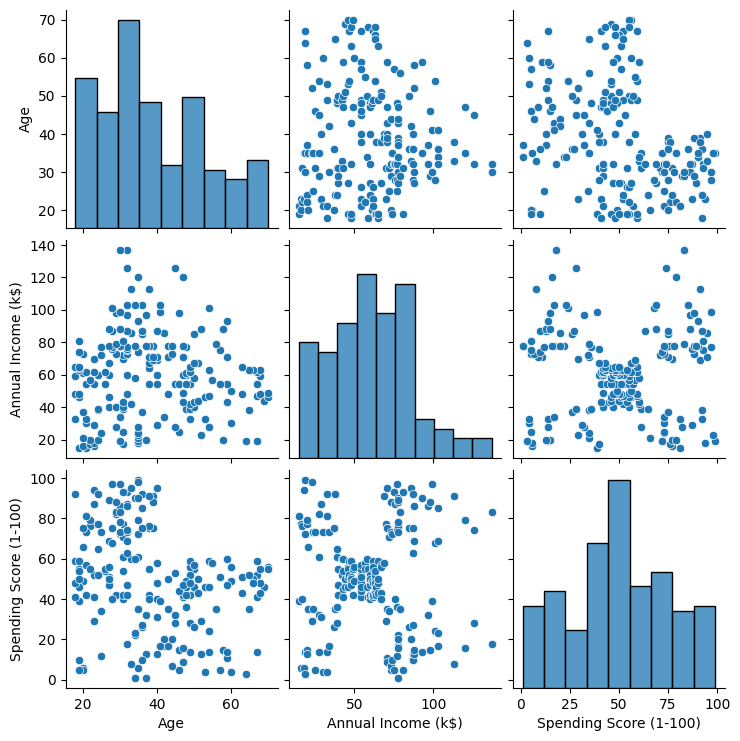

In [3]:
sns.pairplot(dataset.iloc[:, [2, 3, 4]])

## Part One: KMeans Clustering


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch

In [5]:
X = dataset.iloc[:, [3, 4]].values
sc_X = StandardScaler()
X = sc_X.fit_transform(X)
X.shape

(200, 2)

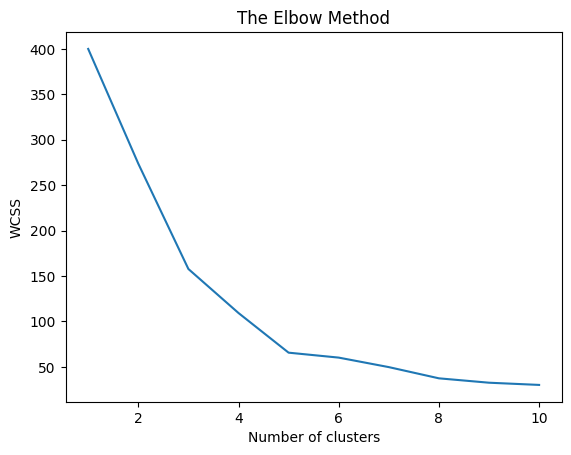

In [6]:
wcss = []
start_index = 1
stop_index = 11

for i in range(start_index, stop_index):
    kmeans = KMeans(n_init="auto", n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(start_index, stop_index), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
num_clusters = 5  # inferred from elbow chart
kmeans = KMeans(
    n_init="auto", n_clusters=num_clusters, init="k-means++", random_state=42
)
y_means = kmeans.fit_predict(X)
y_means

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

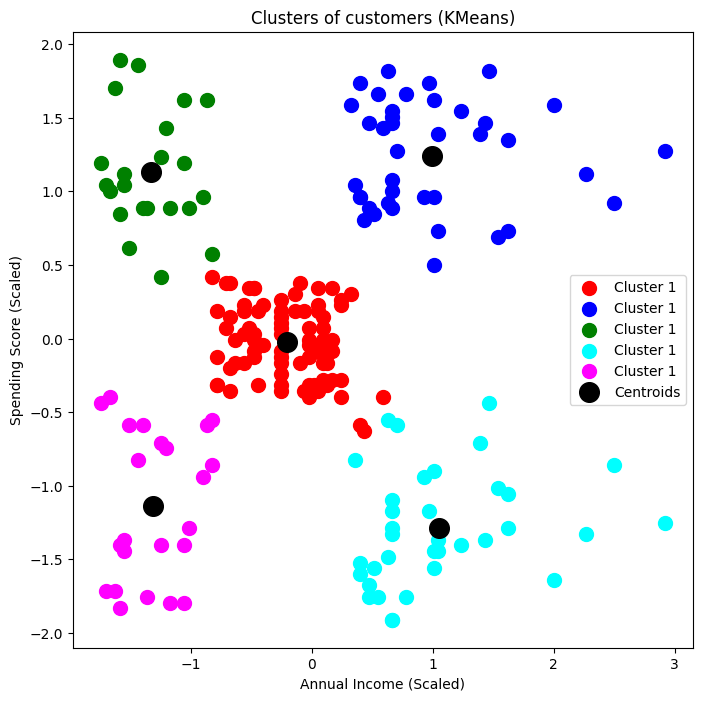

In [8]:
plt.figure(figsize=(8, 8))
colors = ["red", "blue", "green", "cyan", "magenta"]
for j in range(0, num_clusters):
    # creates a mask like so X[True/False, data_column]
    # column 0 for annual income, 1 for spending score
    x_axis = X[y_means == j, 0]
    y_axis = X[y_means == j, 1]
    plt.scatter(x_axis, y_axis, s=100, c=colors[j], label="Cluster 1")

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c="black",
    label="Centroids",
)
plt.title("Clusters of customers (KMeans)")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

## Part Two: Hierarchical Clustering


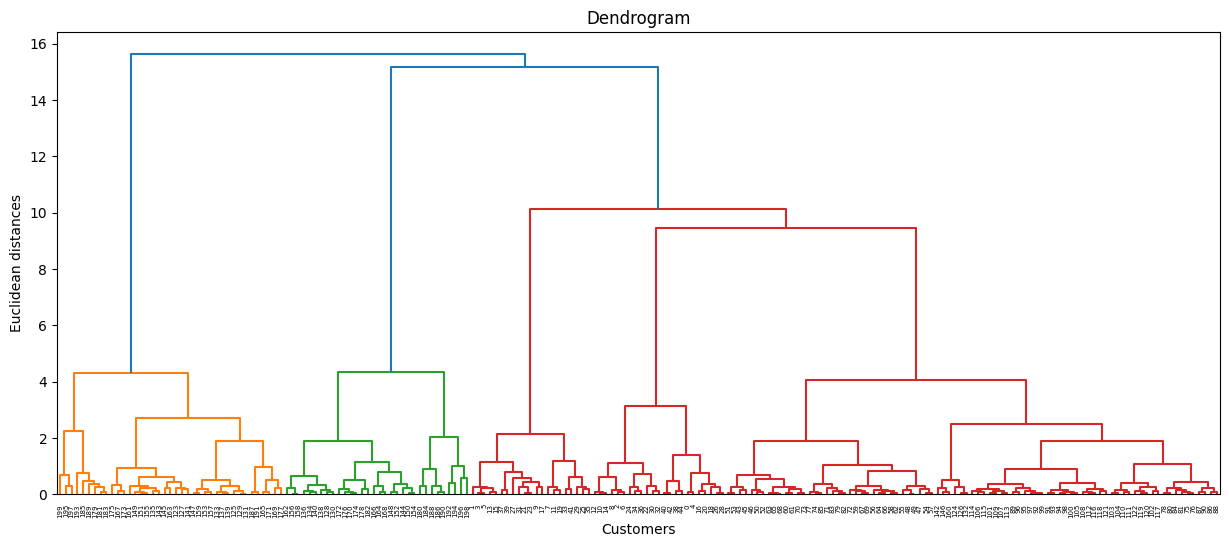

In [9]:
plt.figure(figsize=(15, 6))
Z = sch.linkage(X, method="ward")
dendrogram = sch.dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean distances")
plt.show()

In [10]:
num_clusters = 5
hc = AgglomerativeClustering(
    n_clusters=num_clusters, metric="euclidean", linkage="ward"
)
y_hc = hc.fit_predict(X)
y_hc.shape, y_hc

((200,),
 array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
        4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
        4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
        2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
        0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
        0, 1]))

0
x axis
 (32,) [0.39848884 0.39848884 0.4748277  0.4748277  0.51299713 0.55116656
 0.62750542 0.66567484 0.66567484 0.66567484 0.66567484 0.66567484
 0.66567484 0.78018313 0.93286085 0.97103028 1.00919971 1.00919971
 1.00919971 1.04736914 1.04736914 1.23821628 1.390894   1.42906343
 1.46723286 1.54357172 1.61991057 1.61991057 2.00160487 2.26879087
 2.49780745 2.91767117]
y axis
 (32,) [-1.52180518 -1.5994483  -1.75473454 -1.67709142 -1.56062674 -1.75473454
 -1.48298362 -1.09476801 -1.28887582 -1.17241113 -1.32769738 -1.91002079
 -1.91002079 -1.75473454 -0.93948177 -1.17241113 -0.90066021 -1.44416206
 -1.56062674 -1.44416206 -1.36651894 -1.4053405  -0.7065524  -1.36651894
 -0.43480148 -1.01712489 -1.28887582 -1.05594645 -1.63826986 -1.32769738
 -0.86183865 -1.25005425]
--------------------------------------------------------------------------------
1
x axis
 (39,) [0.32214998 0.36031941 0.39848884 0.39848884 0.39848884 0.43665827
 0.4748277  0.4748277  0.51299713 0.55116656 0.58933599 

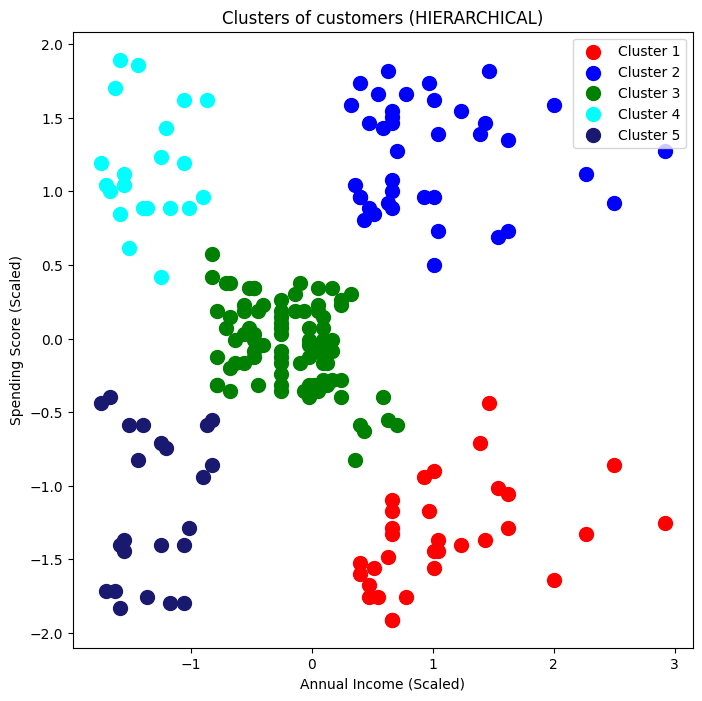

In [11]:
plt.figure(figsize=(8, 8))
colors = ["red", "blue", "green", "cyan", "midnightblue"]
for j in range(0, num_clusters):
    print(j)
    x_axis = X[y_hc == j, 0]
    print('x axis\n', x_axis.shape, x_axis)
    y_axis = X[y_hc == j, 1]
    print('y axis\n', y_axis.shape, y_axis)
    plt.scatter(x_axis, y_axis, s=100, c=colors[j], label=f"Cluster {j+1}")
    print('----'*20)

plt.title("Clusters of customers (HIERARCHICAL)")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

## Part Three: DBSCAN


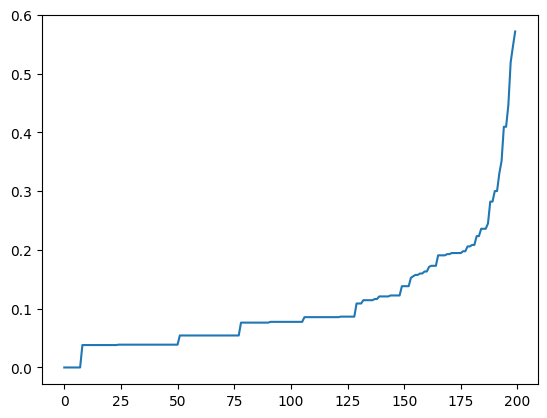

In [12]:
neighbours = NearestNeighbors(n_neighbors=2)
distances, _ = neighbours.fit(X).kneighbors(X)

# print(distances)

distances = distances[:, 1]
distances = np.sort(distances, axis=0)
plt.plot(distances)

In [13]:
dbscan = DBSCAN(eps=0.25, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
y_dbscan

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0, -1, -1, -1,  0, -1,  0,  1,
        0,  1, -1,  1,  0, -1,  0, -1, -1,  1, -1,  1, -1, -1,  0, -1, -1,
       -1, -1, -1, -1, -1, -1,  2, -1,  2,  2, -1,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  3,  2,  3,  2,  3,  4,  3,  4,  3,  2,  3,  4,  3,
        4,  3,  4,  3,  4,  3,  2,  3,  4,  3,  2,  3,  4,  3,  4,  3,  4,
        3,  4,  3,  4,  3,  4,  3,  2,  3,  4,  3, -1, -1,  5,  3, -1, -1,
        5, -1,  5,  3,  5,  3,  5, -1,  5,  3, -1,  3,  5,  3, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

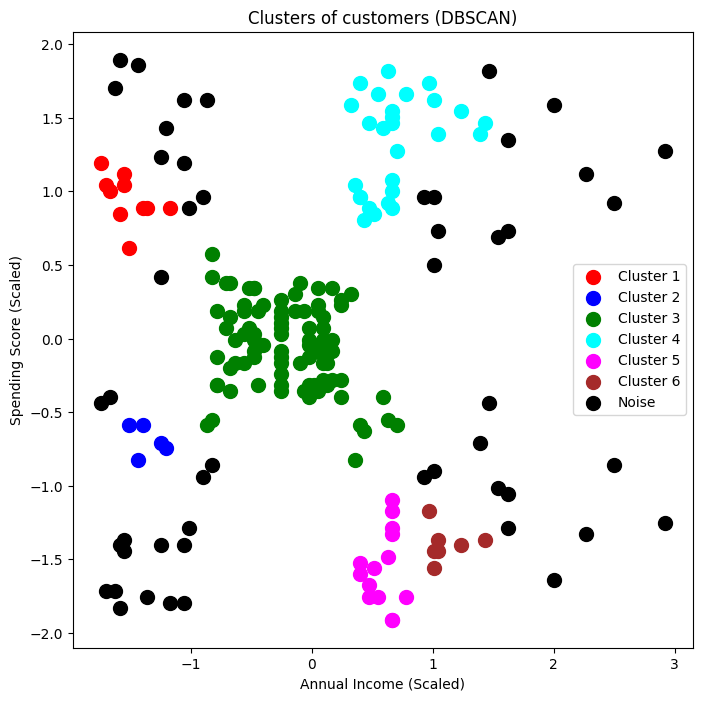

In [14]:
plt.figure(figsize=(8, 8))
colors = ["red", "blue", "green", "cyan", "magenta", "brown"]
for j in range(0, 6):
    x_axis = X[y_dbscan == j, 0]
    y_axis = X[y_dbscan == j, 1]
    plt.scatter(x_axis, y_axis, s=100, c=colors[j], label=f"Cluster {j+1}")

plt.scatter(X[y_dbscan == -1, 0], X[y_dbscan == -1, 1], s=100, c="black", label="Noise")

plt.title("Clusters of customers (DBSCAN)")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

## Part Four: Clustering Data with Higher Dimensionality


In [15]:
financials = pd.read_csv("data/costpercompany.csv")
financials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company       29 non-null     object 
 1   surcharges    29 non-null     float64
 2   RoR           29 non-null     float64
 3   dailycost     29 non-null     int64  
 4   costwithload  29 non-null     float64
 5   costofDemand  29 non-null     float64
 6   Sales         29 non-null     int64  
 7   WearandTear   29 non-null     float64
 8   Fcost         29 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.2+ KB


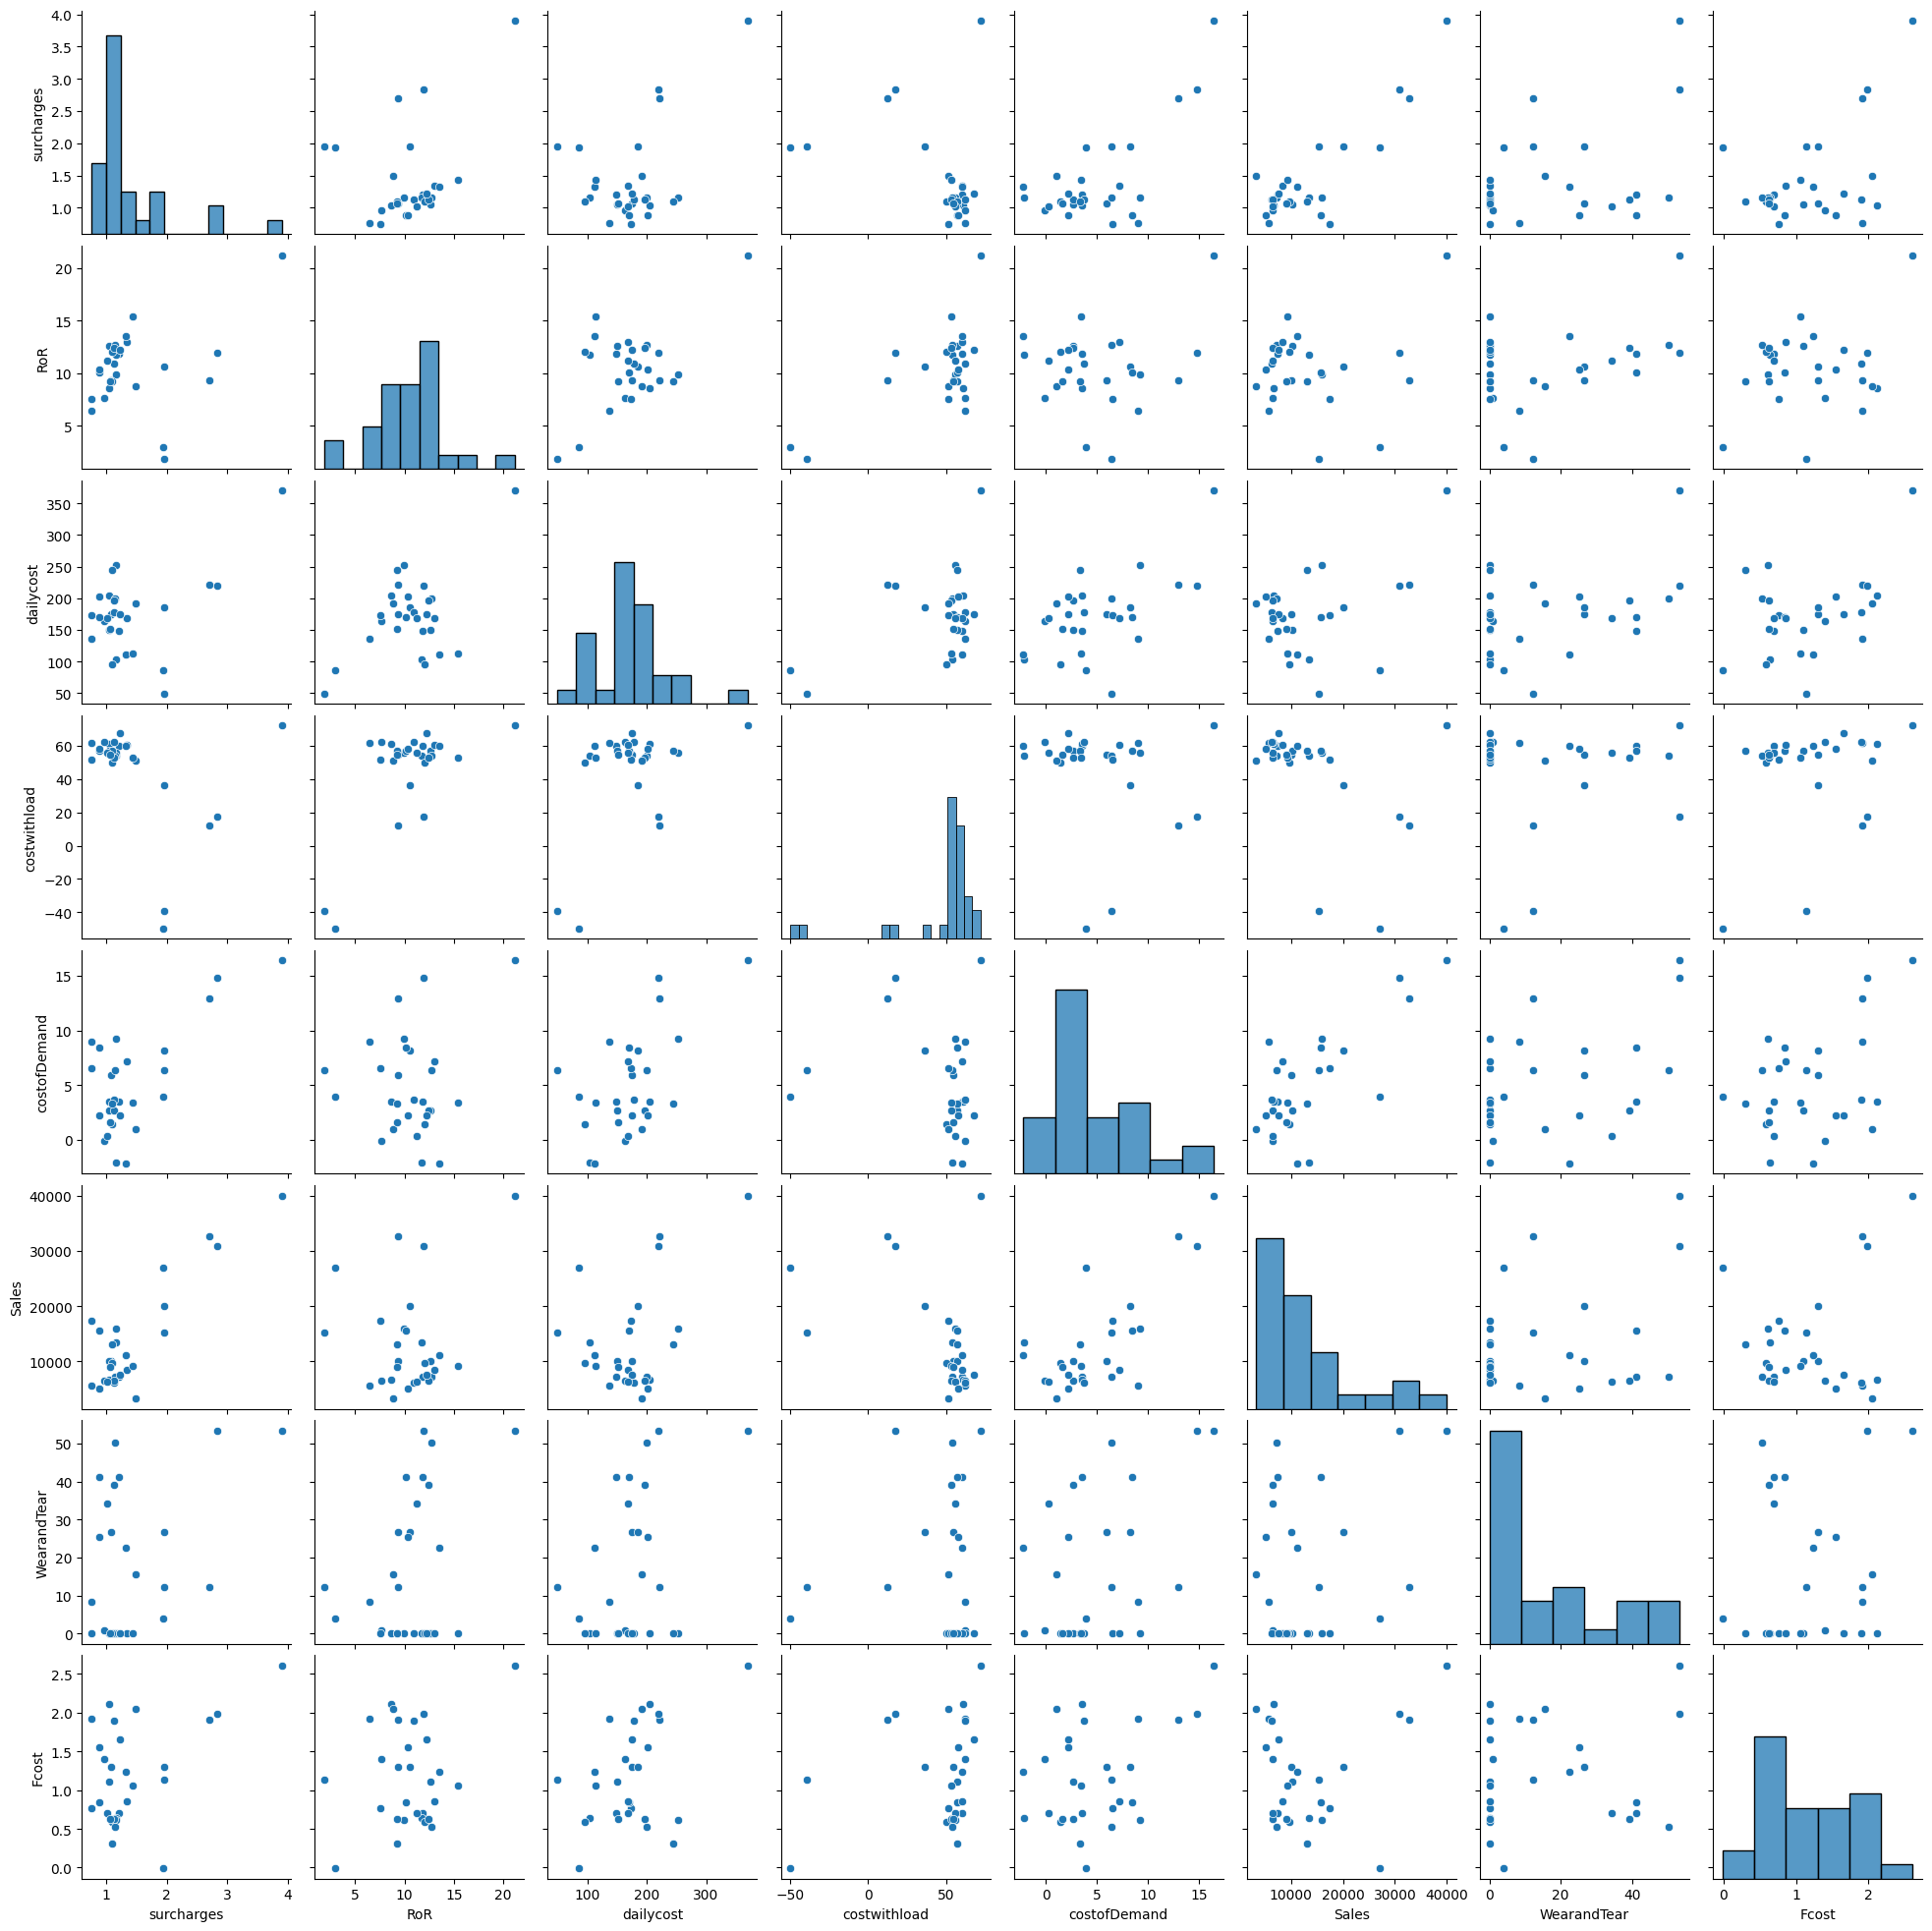

In [16]:
X = financials.iloc[:, 1:9]
sns.pairplot(X)

Text(0, 0.5, 'WCSS')

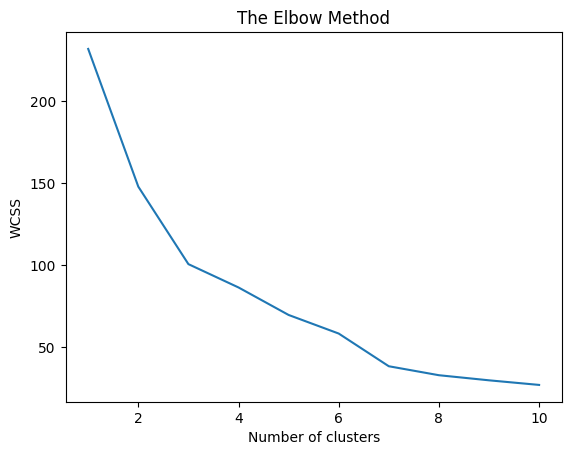

In [17]:
sc_X = StandardScaler()
X = sc_X.fit_transform(X)

wcss = []
start_index = 1
stop_index = 11
for i in range(start_index, stop_index):
    kmeans = KMeans(n_init="auto", n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(start_index, stop_index), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")

In [18]:
high_dim_n_clusters = 4

kmeans = KMeans(n_init="auto", n_clusters=high_dim_n_clusters, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)
y_kmeans

array([1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 2, 0, 3, 2, 0, 0,
       2, 2, 0, 3, 1, 2, 0], dtype=int32)

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

pca.explained_variance_ratio_
print("Sum variance ration: ", sum(pca.explained_variance_ratio_))
X_reduced.shape

Sum variance ration:  0.7056440181560044


(29, 2)

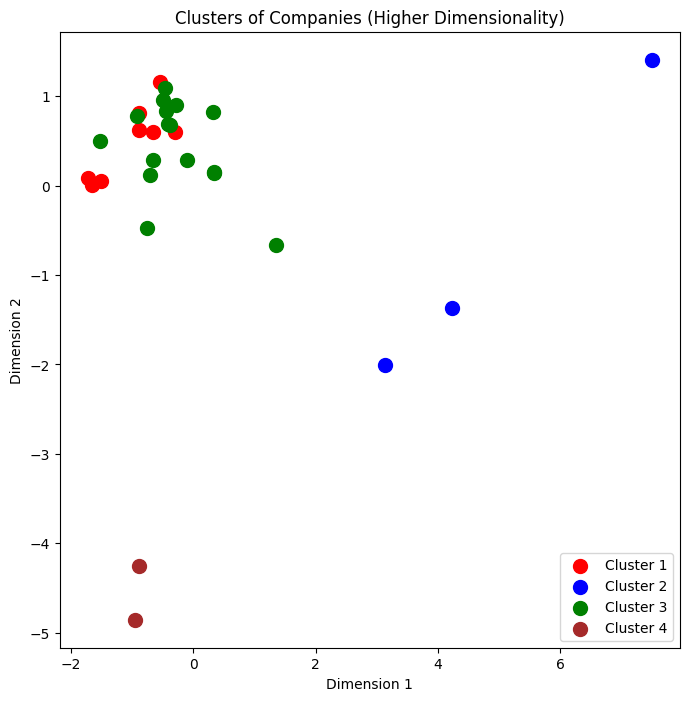

In [26]:
colors = ["red", "blue", "green", "brown"]

plt.figure(figsize=(8, 8))
for i in range(high_dim_n_clusters):
    x_axis = X_reduced[y_kmeans == i, 0]
    y_axis = X_reduced[y_kmeans == i, 1]
    plt.scatter(x_axis, y_axis, s=100, c=colors[i], label=f"Cluster {i+1}")

plt.title("Clusters of Companies (Higher Dimensionality)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np

# Distance matrix from Image 1 (A, B, C, D)
# We represent this as a condensed distance matrix for linkage()
# Distances: AB=1, AC=4, AD=5, BC=2, BD=6, CD=3
distances = np.array([1, 4, 5, 2, 6, 3])

# Perform hierarchical clustering using complete linkage
Z = linkage(distances, method="single")

# Plot dendrogram
plt.figure(figsize=(7, 5))
dendrogram(Z, labels=["A", "B", "C", "D"])
plt.title("Complete Link Agglomerative Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()